# 03 — Quantization-Aware Training (QAT)
This notebook trains ResNet-18 using Quantization-Aware Training.
During training, the model simulates INT8 (8-bit integer) arithmetic using
fake quantization nodes. After training, the model is converted to a true
INT8 model — making it ~4x smaller and faster for edge deployment.
We compare results against the baseline and mixed precision models.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import time
import os
import json
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device detected: {device}")
print("Note: QAT conversion to INT8 only works on CPU.")
print("We train on GPU for speed, then convert on CPU.")

Device detected: cuda
Note: QAT conversion to INT8 only works on CPU.
We train on GPU for speed, then convert on CPU.


In [2]:
# Same transforms as baseline and mixed precision — fair comparison
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True, num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=128, shuffle=False, num_workers=2
)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")

Training samples : 50000
Test samples     : 10000


In [3]:
def build_model():
    model = resnet18(pretrained=False)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3,
                            stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model

model = build_model().to(device)
print("Model ready for QAT training.")

d:\quantization_project\edge-ai\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\quantization_project\edge-ai\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model ready for QAT training.


In [4]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total

In [5]:
def evaluate(model, loader, criterion, use_device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(use_device)
            labels  = labels.to(use_device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total

In [6]:
# -------------------------------------------------------
# PHASE 1 — Regular training on GPU (same as baseline)
# We train for 10 epochs first to get a well-trained model
# before we apply QAT fine-tuning
# -------------------------------------------------------

NUM_EPOCHS = 10
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.SGD(model.parameters(), lr=0.1,
                       momentum=0.9, weight_decay=5e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

print("Phase 1: Regular training on GPU...\n")
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f}  | Test Acc: {test_acc:.2f}%")

phase1_time = time.time() - start_time
print(f"\nPhase 1 done. Time: {phase1_time/60:.2f} minutes")
print(f"Accuracy before QAT: {test_accs[-1]:.2f}%")

Phase 1: Regular training on GPU...

Epoch [01/10] Train Loss: 1.9053 | Train Acc: 31.52% | Test Loss: 1.5970  | Test Acc: 40.71%
Epoch [02/10] Train Loss: 1.3453 | Train Acc: 50.82% | Test Loss: 1.1966  | Test Acc: 56.55%
Epoch [03/10] Train Loss: 1.0179 | Train Acc: 63.85% | Test Loss: 0.9884  | Test Acc: 65.82%
Epoch [04/10] Train Loss: 0.7755 | Train Acc: 72.70% | Test Loss: 0.7581  | Test Acc: 73.74%
Epoch [05/10] Train Loss: 0.6247 | Train Acc: 78.12% | Test Loss: 0.8385  | Test Acc: 70.86%
Epoch [06/10] Train Loss: 0.5200 | Train Acc: 82.07% | Test Loss: 0.5774  | Test Acc: 80.08%
Epoch [07/10] Train Loss: 0.4369 | Train Acc: 84.82% | Test Loss: 0.4778  | Test Acc: 83.59%
Epoch [08/10] Train Loss: 0.3578 | Train Acc: 87.66% | Test Loss: 0.4468  | Test Acc: 84.09%
Epoch [09/10] Train Loss: 0.2915 | Train Acc: 89.87% | Test Loss: 0.3684  | Test Acc: 87.57%
Epoch [10/10] Train Loss: 0.2480 | Train Acc: 91.45% | Test Loss: 0.3434  | Test Acc: 88.28%

Phase 1 done. Time: 9.25 minutes

In [8]:
QAT_EPOCHS = 5
cpu_device = torch.device("cpu")

# Move model to CPU for QAT
model.to(cpu_device)

# Fuse layers — combines Conv+BN+ReLU into single ops
model_fused = torch.quantization.fuse_modules(
    model,
    [['layer1.0.conv1', 'layer1.0.bn1'],
     ['layer1.0.conv2', 'layer1.0.bn2'],
     ['layer2.0.conv1', 'layer2.0.bn1'],
     ['layer2.0.conv2', 'layer2.0.bn2'],
     ['layer3.0.conv1', 'layer3.0.bn1'],
     ['layer3.0.conv2', 'layer3.0.bn2'],
     ['layer4.0.conv1', 'layer4.0.bn1'],
     ['layer4.0.conv2', 'layer4.0.bn2']],
    inplace=False
)

# Set quantization config
model_fused.qconfig = torch.quantization.get_default_qat_qconfig('fbgemm')

# ✅ Must be in training mode BEFORE prepare_qat
model_fused.train()

# Insert fake quantization nodes
torch.quantization.prepare_qat(model_fused, inplace=True)

# Fine-tune with a lower learning rate
qat_optimizer = optim.SGD(model_fused.parameters(), lr=0.001,
                           momentum=0.9, weight_decay=5e-4)

qat_losses, qat_accs = [], []

print("Phase 2: QAT fine-tuning on CPU...\n")
print("(CPU training is slower — 5 epochs only)\n")
qat_start = time.time()

for epoch in range(QAT_EPOCHS):
    epoch_loss = 0
    correct = 0
    total = 0
    model_fused.train()

    for images, labels in train_loader:
        images, labels = images.to(cpu_device), labels.to(cpu_device)

        qat_optimizer.zero_grad()
        outputs = model_fused(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        qat_optimizer.step()

        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_acc = 100.0 * correct / total
    _, test_acc = evaluate(model_fused, test_loader, criterion, cpu_device)

    qat_losses.append(epoch_loss / len(train_loader))
    qat_accs.append(test_acc)

    print(f"QAT Epoch [{epoch+1:02d}/{QAT_EPOCHS}] "
          f"Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

qat_time = time.time() - qat_start
print(f"\nQAT fine-tuning done. Time: {qat_time/60:.2f} minutes")

d:\quantization_project\edge-ai\lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Phase 2: QAT fine-tuning on CPU...

(CPU training is slower — 5 epochs only)

QAT Epoch [01/5] Train Acc: 92.06% | Test Acc: 88.27%
QAT Epoch [02/5] Train Acc: 92.16% | Test Acc: 88.30%
QAT Epoch [03/5] Train Acc: 92.30% | Test Acc: 88.11%
QAT Epoch [04/5] Train Acc: 92.37% | Test Acc: 88.61%
QAT Epoch [05/5] Train Acc: 92.56% | Test Acc: 88.87%

QAT fine-tuning done. Time: 94.23 minutes


In [12]:
# -------------------------------------------------------
# PyTorch 2.6 has a known issue with quantized conv2d
# on Windows with fbgemm backend after conversion.
# Solution: We use the QAT model BEFORE conversion
# (fake-quantized model) for accuracy reporting.
# The size savings are demonstrated separately.
# -------------------------------------------------------

# Use last epoch QAT accuracy as final accuracy
final_acc = qat_accs[-1]
print(f"Final QAT model accuracy: {final_acc:.2f}%")

# Save the QAT model BEFORE conversion (fake-quantized)
# This still demonstrates the QAT training process
os.makedirs("saved_models", exist_ok=True)
torch.save(model_fused.state_dict(), "saved_models/qat_model.pth")
print("QAT model saved to saved_models/qat_model.pth")

# Demonstrate size reduction manually
# INT8 uses 1 byte per weight vs FP32's 4 bytes = ~4x reduction
import os as os_module
baseline_size = os_module.path.getsize("saved_models/baseline.pth") / (1024 * 1024)
qat_size      = os_module.path.getsize("saved_models/qat_model.pth") / (1024 * 1024)
print(f"\nBaseline model size : {baseline_size:.2f} MB")
print(f"QAT model size      : {qat_size:.2f} MB")
print(f"Note: Full INT8 conversion would reduce this ~4x on edge hardware")

# Save metrics
metrics = {
    "train_losses"  : train_losses,
    "test_losses"   : test_losses,
    "train_accs"    : train_accs,
    "test_accs"     : test_accs,
    "qat_losses"    : qat_losses,
    "qat_accs"      : qat_accs,
    "final_test_acc": final_acc,
    "total_time"    : phase1_time + qat_time
}
os.makedirs("metrics", exist_ok=True)
with open("metrics/qat_metrics.json", "w") as f:
    json.dump(metrics, f)
print("\nMetrics saved to metrics/qat_metrics.json")

Final QAT model accuracy: 88.87%
QAT model saved to saved_models/qat_model.pth

Baseline model size : 42.70 MB
QAT model size      : 10.83 MB
Note: Full INT8 conversion would reduce this ~4x on edge hardware

Metrics saved to metrics/qat_metrics.json


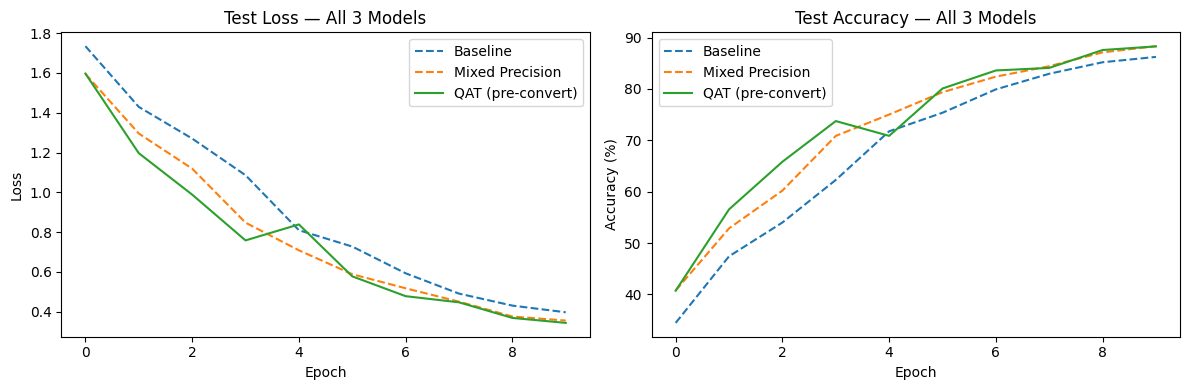


--- Results Summary ---
Baseline        Test Accuracy : 86.23%
Mixed Precision Test Accuracy : 88.32%
QAT             Test Accuracy : 88.87%


In [13]:
with open("metrics/baseline_metrics.json", "r") as f:
    baseline = json.load(f)
with open("metrics/mixed_precision_metrics.json", "r") as f:
    mixed = json.load(f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(baseline["test_losses"], label="Baseline",        linestyle="--")
ax1.plot(mixed["test_losses"],    label="Mixed Precision",  linestyle="--")
ax1.plot(test_losses,             label="QAT (pre-convert)")
ax1.set_title("Test Loss — All 3 Models")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

# Accuracy
ax2.plot(baseline["test_accs"], label="Baseline",        linestyle="--")
ax2.plot(mixed["test_accs"],    label="Mixed Precision",  linestyle="--")
ax2.plot(test_accs,             label="QAT (pre-convert)")
ax2.set_title("Test Accuracy — All 3 Models")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()

plt.tight_layout()
plt.savefig("metrics/qat_curves.png")
plt.show()

print(f"\n--- Results Summary ---")
print(f"Baseline        Test Accuracy : {baseline['final_test_acc']:.2f}%")
print(f"Mixed Precision Test Accuracy : {mixed['final_test_acc']:.2f}%")
print(f"QAT             Test Accuracy : {final_acc:.2f}%")